In [1]:
%matplotlib inline
import numpy as np
import cv2
import matplotlib.pyplot as plt
import copy
from skimage.metrics import structural_similarity, mean_squared_error

In [2]:
# 1. Загрузка
image = cv2.imread('oh.jpg', cv2.IMREAD_GRAYSCALE)
print(image.shape, image.dtype)

(500, 1000) uint8


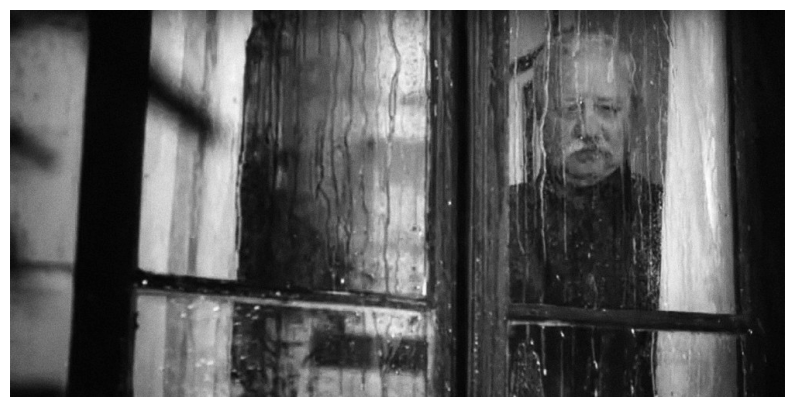

In [3]:
plt.figure(figsize=(10, 6))
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.show()

In [4]:
# 2. Зашумление

In [5]:
# гауссов шум
mean = 0
stddev = 100
noise_gauss = np.zeros(image.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)
image_noise_gauss = cv2.add(image, noise_gauss)

In [6]:
# постоянный шум
noise_range = 50
noise_uniform = np.random.uniform(-noise_range, noise_range, size=image.shape).astype(np.int16)

image_with_noise = image.astype(np.int16) + noise_uniform
image_noise_uniform = np.clip(image_with_noise, 0, 255).astype(np.uint8)

In [7]:
# метрики
def evaluate(original, filtered, name):
    mse = mean_squared_error(original, filtered)
    ssim = structural_similarity(original, filtered, full=True)[0]
    return {"name": name, "MSE": mse, "SSIM": ssim}

baseline_results = [
    evaluate(image, image_noise_gauss, "Gauss noise"),
    evaluate(image, image_noise_uniform,        "Const"),
]

for r in baseline_results:
    print(f"{r['name']:20s}  MSE = {r['MSE']:.2f}   SSIM = {r['SSIM']:.4f}")

Gauss noise           MSE = 3418.40   SSIM = 0.1219
Const                 MSE = 800.99   SSIM = 0.2186


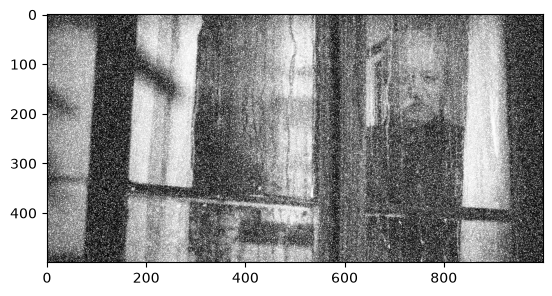

In [8]:
plt.imshow(image_noise_gauss, cmap="gray")

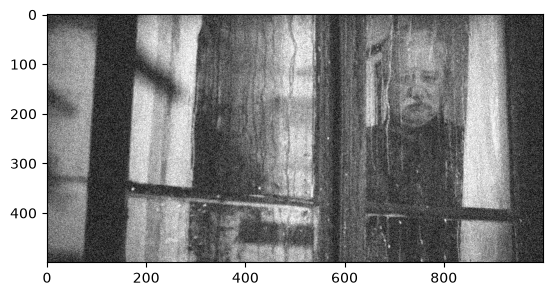

In [9]:
plt.imshow(image_noise_uniform, cmap="gray")

In [10]:
# 3. Фильтрация
results = []

In [11]:
# 1) медианный
for ksize in [3, 5, 7]:
    img_g = cv2.medianBlur(image_noise_gauss, ksize)
    img_s = cv2.medianBlur(image_noise_uniform, ksize)
    r_g = evaluate(image, img_g, 'медианный')
    r_s = evaluate(image, img_s, 'медианный')
    print(f"k={ksize}: gauss MSE={r_g['MSE']:.2f} SSIM={r_g['SSIM']:.4f} | "
          f"sp MSE={r_s['MSE']:.2f} SSIM={r_s['SSIM']:.4f}")
    r_g.update({"noise": "gauss", "ksize": ksize})
    results.append(r_g)
    r_s.update({"noise": "const", "ksize": ksize})
    results.append(r_s)

k=3: gauss MSE=827.44 SSIM=0.3147 | sp MSE=227.21 SSIM=0.4306
k=5: gauss MSE=412.80 SSIM=0.5090 | sp MSE=118.50 SSIM=0.5919
k=7: gauss MSE=337.21 SSIM=0.5920 | sp MSE=102.59 SSIM=0.6538


In [12]:
# 2) гаусса
for ksize in [(3, 3), (5, 5), (7, 7)]:
    for sigma in [0, 1, 2]:
        img_g = cv2.GaussianBlur(image_noise_gauss, ksize, sigma)
        img_s = cv2.GaussianBlur(image_noise_uniform, ksize, sigma)
        r_g = evaluate(image, img_g, 'гаусса')
        r_s = evaluate(image, img_s, 'гаусса')
        print(f"Гаусса ksize={ksize} sigma={sigma}:  gauss MSE={r_g['MSE']:.2f} SSIM={r_g['SSIM']:.4f}  |  "
              f"sp MSE={r_s['MSE']:.2f} SSIM={r_s['SSIM']:.4f}")
        r_g.update({"noise": "gauss", "ksize": ksize, "sigma": sigma})
        results.append(r_g)
        r_s.update({"noise": "const", "ksize": ksize, "sigma": sigma})
        results.append(r_s)

Гаусса ksize=(3, 3) sigma=0:  gauss MSE=1526.99 SSIM=0.3700  |  sp MSE=122.77 SSIM=0.5697
Гаусса ksize=(3, 3) sigma=1:  gauss MSE=1493.87 SSIM=0.3875  |  sp MSE=112.47 SSIM=0.5894
Гаусса ksize=(3, 3) sigma=2:  gauss MSE=1465.90 SSIM=0.4018  |  sp MSE=104.33 SSIM=0.6038
Гаусса ksize=(5, 5) sigma=0:  gauss MSE=1386.97 SSIM=0.4764  |  sp MSE=77.08 SSIM=0.6801
Гаусса ksize=(5, 5) sigma=1:  gauss MSE=1403.81 SSIM=0.4584  |  sp MSE=82.21 SSIM=0.6641
Гаусса ksize=(5, 5) sigma=2:  gauss MSE=1329.30 SSIM=0.5578  |  sp MSE=63.49 SSIM=0.7387
Гаусса ksize=(7, 7) sigma=0:  gauss MSE=1322.69 SSIM=0.5736  |  sp MSE=60.47 SSIM=0.7522
Гаусса ksize=(7, 7) sigma=1:  gauss MSE=1396.65 SSIM=0.4655  |  sp MSE=79.98 SSIM=0.6707
Гаусса ksize=(7, 7) sigma=2:  gauss MSE=1305.08 SSIM=0.6204  |  sp MSE=61.46 SSIM=0.7698


In [13]:
# 3) билатеральный
for d in [5, 9, 15]:
    for sigma_color in [50, 75, 100]:
        for sigma_space in [50, 75, 100]:
            img_g = cv2.bilateralFilter(image_noise_gauss, d, sigma_color, sigma_space)
            img_s = cv2.bilateralFilter(image_noise_uniform, d, sigma_color, sigma_space)
            r_g = evaluate(image, img_g, 'билатеральный')
            r_s = evaluate(image, img_s, 'билатеральный')
            print(f"Билатеральный d={d} σс={sigma_color} σs={sigma_space}:  "
                  f"gauss MSE={r_g['MSE']:.2f} SSIM={r_g['SSIM']:.4f}  |  "
                  f"sp MSE={r_s['MSE']:.2f} SSIM={r_s['SSIM']:.4f}")
            r_g.update({"noise": "gauss", "d": d, "sigmaColor": sigma_color, "sigmaSpace": sigma_space})
            results.append(r_g)
            r_s.update({"noise": "const", "d": d, "sigmaColor": sigma_color, "sigmaSpace": sigma_space})
            results.append(r_s)

Билатеральный d=5 σс=50 σs=50:  gauss MSE=2180.81 SSIM=0.2239  |  sp MSE=148.84 SSIM=0.5283
Билатеральный d=5 σс=50 σs=75:  gauss MSE=2180.74 SSIM=0.2239  |  sp MSE=148.84 SSIM=0.5283
Билатеральный d=5 σс=50 σs=100:  gauss MSE=2180.72 SSIM=0.2239  |  sp MSE=148.83 SSIM=0.5283
Билатеральный d=5 σс=75 σs=50:  gauss MSE=1551.67 SSIM=0.3117  |  sp MSE=98.81 SSIM=0.6216
Билатеральный d=5 σс=75 σs=75:  gauss MSE=1551.61 SSIM=0.3117  |  sp MSE=98.81 SSIM=0.6217
Билатеральный d=5 σс=75 σs=100:  gauss MSE=1551.60 SSIM=0.3117  |  sp MSE=98.81 SSIM=0.6217
Билатеральный d=5 σс=100 σs=50:  gauss MSE=1324.56 SSIM=0.3798  |  sp MSE=87.72 SSIM=0.6480
Билатеральный d=5 σс=100 σs=75:  gauss MSE=1324.52 SSIM=0.3798  |  sp MSE=87.72 SSIM=0.6480
Билатеральный d=5 σс=100 σs=100:  gauss MSE=1324.51 SSIM=0.3798  |  sp MSE=87.72 SSIM=0.6480
Билатеральный d=9 σс=50 σs=50:  gauss MSE=2005.54 SSIM=0.2330  |  sp MSE=114.94 SSIM=0.5820
Билатеральный d=9 σс=50 σs=75:  gauss MSE=2005.47 SSIM=0.2330  |  sp MSE=114.94 

In [14]:
# 4) нелокальных средних
for h in [5, 10, 20, 30]:
    for tw in [5, 7]:
        for sw in [15, 21]:
            img_g = cv2.fastNlMeansDenoising(image_noise_gauss, h=h, templateWindowSize=tw, searchWindowSize=sw)
            img_s = cv2.fastNlMeansDenoising(image_noise_uniform, h=h, templateWindowSize=tw, searchWindowSize=sw)
            r_g = evaluate(image, img_g, 'нелокальных средних')
            r_s = evaluate(image, img_s, 'нелокальных средних')
            print(f"Нелокальных средних h={h} tw={tw} sw={sw}:  "
                  f"gauss MSE={r_g['MSE']:.2f} SSIM={r_g['SSIM']:.4f}  |  "
                  f"sp MSE={r_s['MSE']:.2f} SSIM={r_s['SSIM']:.4f}")
            r_g.update({"noise": "gauss", "h": h, "tw": tw, "sw": sw})
            results.append(r_g)
            r_s.update({"noise": "const", "h": h, "tw": tw, "sw": sw})
            results.append(r_s)

Нелокальных средних h=5 tw=5 sw=15:  gauss MSE=3418.32 SSIM=0.1222  |  sp MSE=800.99 SSIM=0.2186
Нелокальных средних h=5 tw=5 sw=21:  gauss MSE=3418.30 SSIM=0.1223  |  sp MSE=800.99 SSIM=0.2186
Нелокальных средних h=5 tw=7 sw=15:  gauss MSE=3418.35 SSIM=0.1221  |  sp MSE=800.99 SSIM=0.2186
Нелокальных средних h=5 tw=7 sw=21:  gauss MSE=3418.34 SSIM=0.1222  |  sp MSE=800.99 SSIM=0.2186
Нелокальных средних h=10 tw=5 sw=15:  gauss MSE=3411.35 SSIM=0.1319  |  sp MSE=800.77 SSIM=0.2187
Нелокальных средних h=10 tw=5 sw=21:  gauss MSE=3409.89 SSIM=0.1340  |  sp MSE=800.63 SSIM=0.2187
Нелокальных средних h=10 tw=7 sw=15:  gauss MSE=3412.73 SSIM=0.1310  |  sp MSE=800.98 SSIM=0.2186
Нелокальных средних h=10 tw=7 sw=21:  gauss MSE=3411.72 SSIM=0.1329  |  sp MSE=800.97 SSIM=0.2186
Нелокальных средних h=20 tw=5 sw=15:  gauss MSE=3257.34 SSIM=0.1800  |  sp MSE=141.80 SSIM=0.5421
Нелокальных средних h=20 tw=5 sw=21:  gauss MSE=3213.05 SSIM=0.1872  |  sp MSE=109.03 SSIM=0.6063
Нелокальных средних h=20

In [15]:
# 4. Сбор результатов
import pandas as pd

df = pd.DataFrame(results)
df = df[["name", "noise", "MSE", "SSIM", "ksize", "sigma",
         "d", "sigmaColor", "sigmaSpace", "h", "tw", "sw"]]
df

,name,noise,MSE,SSIM,ksize,sigma,d,sigmaColor,sigmaSpace,h,tw,sw
0,медианный,gauss,827.438840,0.314676,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,медианный,const,227.205128,0.430624,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,медианный,gauss,412.797330,0.508989,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,медианный,const,118.500410,0.591923,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,медианный,gauss,337.213270,0.591975,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
105,нелокальных средних,const,69.106782,0.745001,NaN,NaN,NaN,NaN,NaN,30.0,5.0,21.0
106,нелокальных средних,gauss,2224.682278,0.293653,NaN,NaN,NaN,NaN,NaN,30.0,7.0,15.0
107,нелокальных средних,const,66.731128,0.746341,NaN,NaN,NaN,NaN,NaN,30.0,7.0,15.0
108,нелокальных средних,gauss,1987.576290,0.323752,NaN,NaN,NaN,NaN,NaN,30.0,7.0,21.0


In [16]:
# 5. Вывод
best_ssim = (df.sort_values("SSIM", ascending=False)
               .groupby("noise", as_index=False)
               .head(1))

best_mse = (df.sort_values("MSE", ascending=True)
              .groupby("noise", as_index=False)
              .head(1))

print("Топ-1 по SSIM")
print(best_ssim[["noise", "name", "MSE", "SSIM",
                 "ksize", "sigma", "d", "sigmaColor", "sigmaSpace", "h", "tw", "sw"]]
      .to_string(index=False))

print("\nТоп-1 по MSE")
print(best_mse[["noise", "name", "MSE", "SSIM",
                "ksize", "sigma", "d", "sigmaColor", "sigmaSpace", "h", "tw", "sw"]]
      .to_string(index=False))

Топ-1 по SSIM
noise   name         MSE     SSIM  ksize  sigma   d  sigmaColor  sigmaSpace   h  tw  sw
const гаусса   61.459552 0.769785 (7, 7)    2.0 NaN         NaN         NaN NaN NaN NaN
gauss гаусса 1305.076524 0.620354 (7, 7)    2.0 NaN         NaN         NaN NaN NaN NaN

Топ-1 по MSE
noise      name        MSE     SSIM  ksize  sigma   d  sigmaColor  sigmaSpace   h  tw  sw
const    гаусса  60.473808 0.752239 (7, 7)    0.0 NaN         NaN         NaN NaN NaN NaN
gauss медианный 337.213270 0.591975      7    NaN NaN         NaN         NaN NaN NaN NaN
